In [26]:
import pandas as pd

df = pd.read_parquet('../data/Player-Games_Injuries_Travel_Bio.parquet')

In [27]:
pi_mean = df['positionless_index'].mean()
pi_std = df['positionless_index'].std()
df['positionless_z'] = (df['positionless_index'] - pi_mean) / pi_std

# From 014_injury_prediction.ipynb
kept_features = ['rolling_3g_field_goals_made',
                 'rolling_3g_three_pointers_made',
                 'rolling_3g_points_per36',
                 'rolling_3g_three_point_percent',
                 'rolling_7g_three_point_percent',
                 'rolling_3g_points', 'rolling_7g_rebounds',
                 'rolling_3g_assists_per36', 'rolling_7g_blocks',
                 'rolling_3g_steals', 'rolling_7g_assists_per36',
                 'rolling_7g_turnovers', 'games_last_14d',
                 'rolling_7g_points_per36', 'rolling_3g_turnovers',
                 'rolling_3g_field_goals_attempted',
                 'rolling_7g_minutes', 'rolling_3g_assists',
                 'rolling_3g_three_pointers_attempted',
                 'rolling_7g_USG', 'rolling_7g_3p_relative_percent',
                 'rolling_7g_field_goals_made',
                 'rolling_7g_steals',
                 'rolling_7g_assists', 'winPercent_team',
                 'rolling_7g_three_pointers_attempted',
                 'rolling_7g_ft_relative_percent',
                 'rolling_3g_3p_relative_percent', 'rolling_7g_points',
                 'rolling_7g_three_pointers_made',
                 'rolling_7g_field_goals_attempted', 'rolling_3g_USG']
for c in kept_features:
  df[f'{c}_z'] = (df[c] - df[c].mean()) / df[c].std()

In [28]:
from sklearn.impute import SimpleImputer

cols = (
    ["injury_within_14d", "positionless_z", "personId"]
    + [f"{f}_z" for f in kept_features]
)

imputer = SimpleImputer(strategy="median")
df[cols] = imputer.fit_transform(df[cols])

In [29]:
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import false_discovery_control

results = []

for f in kept_features:
  formula = f'injury_within_14d ~ + positionless_z + {f}_z + positionless_z:{f}_z'
  model = smf.logit(formula, data=df).fit(maxiter=2000,
                                          cov_type='cluster',
                                          cov_kwds={'groups': df['personId']})
  interaction_term = f'positionless_z:{f}_z'
  if interaction_term not in model.params.index:
    interaction_term = f'{f}_z:positionless_z'
  coef = model.params[interaction_term]
  results.append({
      'feature': f,
      'interaction_coef': coef,
      'interaction_p': model.pvalues[interaction_term],
      'interaction_se': model.bse[interaction_term],
      'interaction_z': model.tvalues[interaction_term],
      'ci_95_low': model.conf_int().loc[interaction_term, 0],
      'ci_95_high': model.conf_int().loc[interaction_term, 1],
      'or_interaction': np.exp(coef),
      'main_effect_coef': model.params[f'{f}_z'],
      'main_effect_p': model.pvalues[f'{f}_z'],
      'n': int(model.nobs)
  })

results = pd.DataFrame(results)
results['adj_interaction_p'] = false_discovery_control(results['interaction_p'])
results['adj_main_effect_p'] = false_discovery_control(results['main_effect_p'])

results = results.sort_values("interaction_p").reset_index(drop=True)

results.head(20)

Optimization terminated successfully.
         Current function value: 0.332327
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.335030
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.333668
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.338181
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.337288
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.331637
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.336762
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.337209
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.338594
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.338441
  

,feature,interaction_coef,interaction_p,interaction_se,interaction_z,ci_95_low,ci_95_high,or_interaction,main_effect_coef,main_effect_p,n,adj_interaction_p,adj_main_effect_p
0,rolling_7g_three_pointers_attempted,0.090929,0.000008,0.020406,4.455949,0.050933,0.130924,1.095191,0.389570,1.818691e-41,333158,0.000267,6.466456e-41
1,rolling_3g_three_pointers_attempted,0.077944,0.000071,0.019625,3.971638,0.039479,0.116408,1.081062,0.359903,5.178779e-42,333158,0.000962,2.762015e-41
2,rolling_7g_assists,0.062780,0.000090,0.016034,3.915526,0.031355,0.094205,1.064792,0.317601,9.889976e-30,333158,0.000962,1.977995e-29
3,rolling_7g_three_pointers_made,0.071428,0.000205,0.019240,3.712466,0.033718,0.109138,1.074041,0.342766,5.656608e-39,333158,0.001642,1.645559e-38
4,rolling_3g_assists,0.054214,0.000421,0.015372,3.526730,0.024085,0.084344,1.055711,0.298834,2.392324e-31,333158,0.002693,5.103624e-31
5,rolling_7g_3p_relative_percent,0.061562,0.002978,0.020728,2.970032,0.020937,0.102188,1.063497,0.223676,1.829960e-17,333158,0.013746,2.546031e-17
6,rolling_3g_three_pointers_made,0.052020,0.003396,0.017758,2.929385,0.017215,0.086825,1.053397,0.295259,2.479260e-39,333158,0.013746,7.933631e-39
7,rolling_7g_three_point_percent,0.060896,0.003437,0.020814,2.925726,0.020101,0.101691,1.062788,0.242142,1.139051e-20,333158,0.013746,1.918401e-20
8,rolling_3g_points_per36,-0.039065,0.027511,0.017723,-2.204190,-0.073802,-0.004328,0.961688,0.343582,4.903872e-36,333158,0.097817,1.120885e-35
9,rolling_7g_assists_per36,0.034343,0.051194,0.017613,1.949851,-0.000178,0.068865,1.034940,0.244586,2.060986e-16,333158,0.149071,2.536599e-16


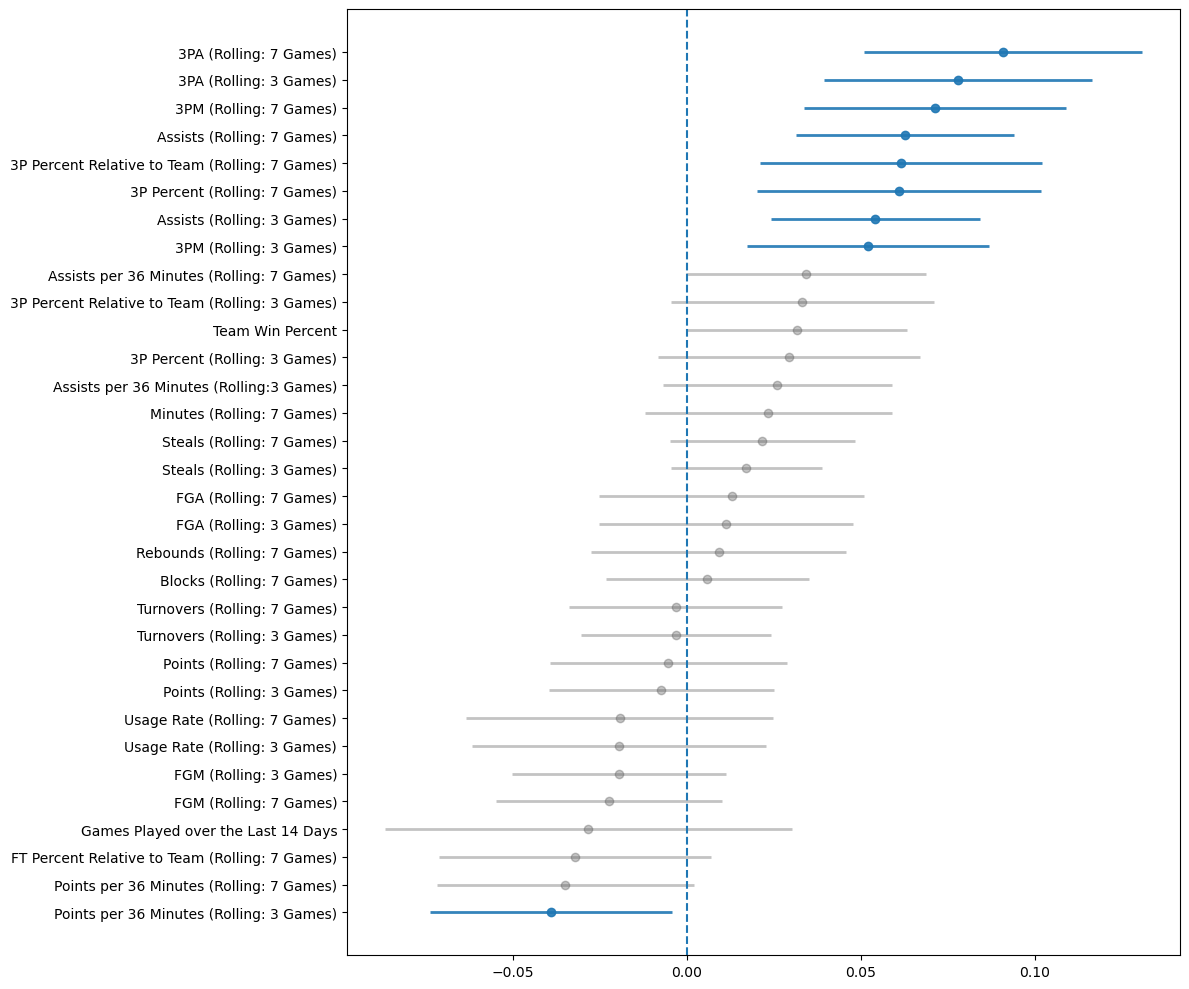

In [30]:
import matplotlib.pyplot as plt

results = results.sort_values('interaction_coef')

results['feature'] = results['feature'].map({
    'rolling_7g_three_pointers_attempted': '3PA (Rolling: 7 Games)',
    'rolling_3g_three_pointers_attempted': '3PA (Rolling: 3 Games)',
    'rolling_7g_three_pointers_made': '3PM (Rolling: 7 Games)',
    'rolling_7g_assists': 'Assists (Rolling: 7 Games)',
    'rolling_7g_3p_relative_percent': '3P Percent Relative to Team (Rolling: 7 Games)',
    'rolling_7g_three_point_percent': '3P Percent (Rolling: 7 Games)',
    'rolling_3g_assists': 'Assists (Rolling: 3 Games)',
    'rolling_3g_three_pointers_made': '3PM (Rolling: 3 Games)',
    'rolling_7g_assists_per36': 'Assists per 36 Minutes (Rolling: 7 Games)',
    'rolling_3g_3p_relative_percent': '3P Percent Relative to Team (Rolling: 3 Games)',
    'winPercent_team': 'Team Win Percent',
    'rolling_3g_three_point_percent': '3P Percent (Rolling: 3 Games)',
    'rolling_3g_assists_per36': 'Assists per 36 Minutes (Rolling:3 Games)',
    'rolling_7g_minutes': 'Minutes (Rolling: 7 Games)',
    'rolling_7g_steals': 'Steals (Rolling: 7 Games)',
    'rolling_3g_steals': 'Steals (Rolling: 3 Games)',
    'rolling_7g_field_goals_attempted': 'FGA (Rolling: 7 Games)',
    'rolling_3g_field_goals_attempted': 'FGA (Rolling: 3 Games)',
    'rolling_7g_rebounds': 'Rebounds (Rolling: 7 Games)',
    'rolling_7g_blocks': 'Blocks (Rolling: 7 Games)',
    'rolling_7g_turnovers': 'Turnovers (Rolling: 7 Games)',
    'rolling_3g_turnovers': 'Turnovers (Rolling: 3 Games)',
    'rolling_7g_points': 'Points (Rolling: 7 Games)',
    'rolling_3g_points': 'Points (Rolling: 3 Games)',
    'rolling_7g_USG': 'Usage Rate (Rolling: 7 Games)',
    'rolling_3g_USG': 'Usage Rate (Rolling: 3 Games)',
    'rolling_3g_field_goals_made': 'FGM (Rolling: 3 Games)',
    'rolling_7g_field_goals_made': 'FGM (Rolling: 7 Games)',
    'games_last_14d': 'Games Played over the Last 14 Days',
    'rolling_7g_ft_relative_percent': 'FT Percent Relative to Team (Rolling: 7 Games)',
    'rolling_7g_points_per36': 'Points per 36 Minutes (Rolling: 7 Games)',
    'rolling_3g_points_per36': 'Points per 36 Minutes (Rolling: 3 Games)'
})

y = np.arange(len(results))

fig, ax = plt.subplots(figsize=(12,10))

is_sig = results['interaction_p'] <= 0.05

for i in range(len(results)):
    color = '#1f77b4' if is_sig.iloc[i] else '#555555'
    alpha = 0.9 if is_sig.iloc[i] else 0.35

    ax.hlines(
        y[i],
        results['ci_95_low'].iloc[i],
        results['ci_95_high'].iloc[i],
        color=color,
        alpha=alpha,
        linewidth=2
    )

    ax.scatter(results['interaction_coef'].iloc[i], y[i], color=color, alpha=alpha)

plt.axvline(0,linestyle='--')

plt.yticks(y, results['feature'])

plt.tight_layout()
plt.show()

In [31]:
plt.savefig(
    "../output/Figures/Interaction Regression Forest Plot.svg",
    format="svg",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

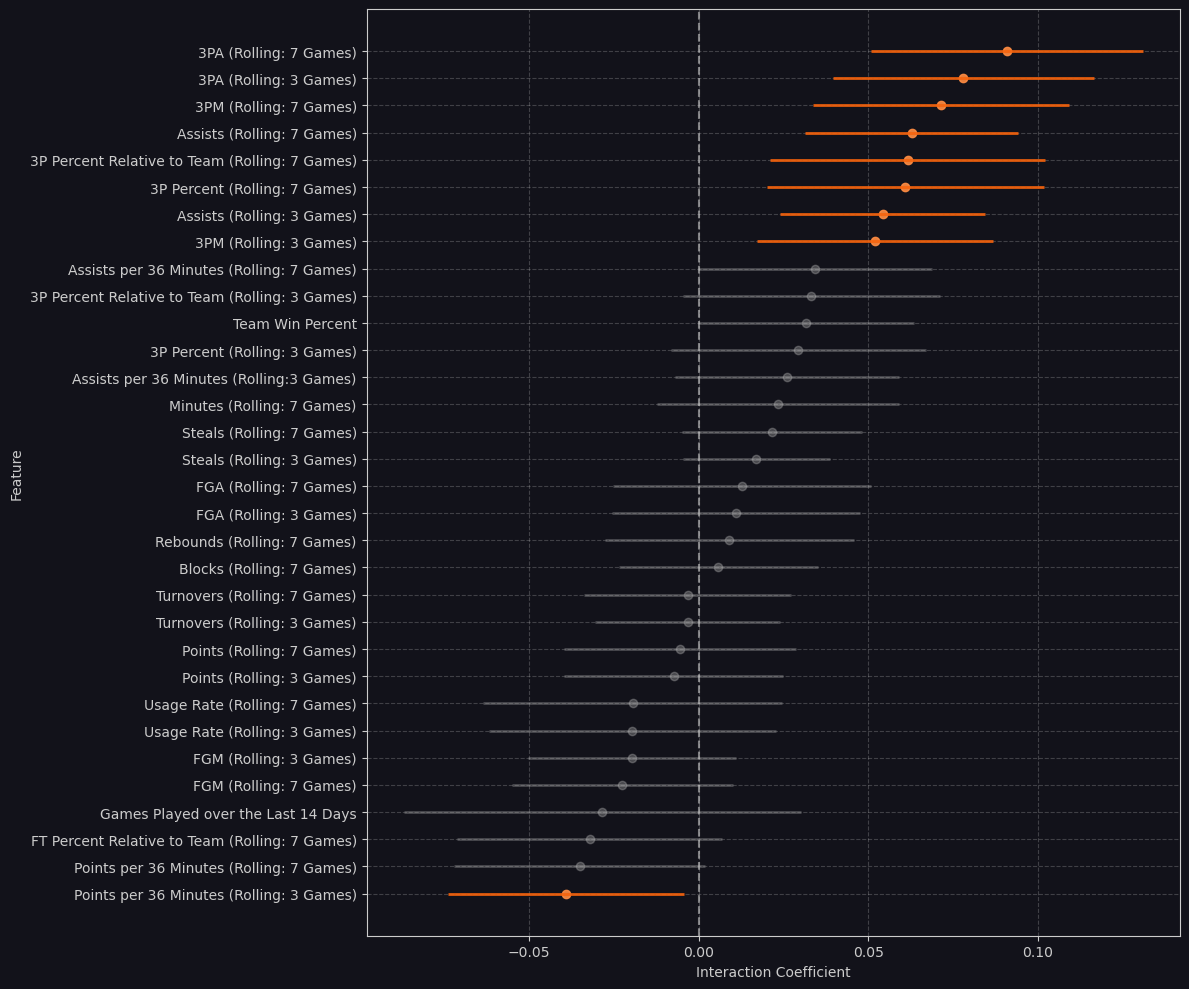

In [32]:
import matplotlib.pyplot as plt
import numpy as np

BG = '#12121a'
LINE = '#f7630c'
POINT = '#ff8c42'
TEXT = '#cccccc'
GRID = '#cccccc'

fig, ax = plt.subplots(figsize=(12, 10))

# Background
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for i in range(len(results)):
    color = LINE if is_sig.iloc[i] else '#b0b0b0'
    alpha = 0.9 if is_sig.iloc[i] else 0.35

    ax.hlines(
        y[i],
        results['ci_95_low'].iloc[i],
        results['ci_95_high'].iloc[i],
        color=color,
        alpha=alpha,
        linewidth=2
    )

    ax.scatter(results['interaction_coef'].iloc[i], y[i], color= POINT if is_sig.iloc[i] else '#b0b0b0',
               alpha=alpha)

# Zero reference line
ax.axvline(
    0,
    linestyle='--',
    color=TEXT,
    alpha=0.6
)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(results['feature'], color=TEXT)

# Labels + title (optional)
ax.set_xlabel('Interaction Coefficient', color=TEXT)
ax.set_ylabel('Feature', color=TEXT)

# Styling
ax.tick_params(colors=TEXT)

for spine in ax.spines.values():
    spine.set_color(TEXT)

ax.grid(
    True,
    linestyle='--',
    color=GRID,
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [33]:
fig.savefig(
    "website/positionless-analytics/public/Interaction Regression Forest Plot.svg",
    format="svg",
    bbox_inches="tight"
)